## Download Tiles

#### Dependencies

In [1]:
import os

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
from owslib.wms import WebMapService

from detect_wildlife_crossings.wms.helpers import download_images_parallel

#### Config

In [ ]:
output_dir = "E:/cassda-data/street-tiles/CH"
box_source = "../data/geodata/CH_Export_Box_on_Highway.json"
buffer_size = 640  # meter buffer around each point, square bbox

WMS_URL = "https://image.discomap.eea.europa.eu/arcgis/services/GioLand/VHR_2021_LAEA/ImageServer/WMSServer/?request=GetCapabilities&service=WMS"
CRS = "EPSG:3035"  # ETRS89 / ETRS-LAEA
PIXEL_RESOLUTION_M = 2  # 2 meters per pixel

#### Setup

In [4]:
gdf = gpd.read_file(box_source)
gdf.head()

gdf_ch = gpd.read_file(
    r"C:\Users\raffael\FHNW\P-cassda-wildtieruebergaenge_M365 - General\data\exploration\swissBOUNDARIES3D_1_5_LV95_LN02.gpkg",
    layer="TLM_LANDESGEBIET",
)
gdf_ch = gdf_ch.to_crs(CRS)

# remove points outside Switzerland
gdf = gdf[gdf.within(gdf_ch.union_all())]

In [5]:
wms = WebMapService(
    WMS_URL,
    version="1.3.0",
)
layer_name = list(wms.contents)[0]
print(layer_name)

VHR_2021_LAEA


#### Plot Dataset

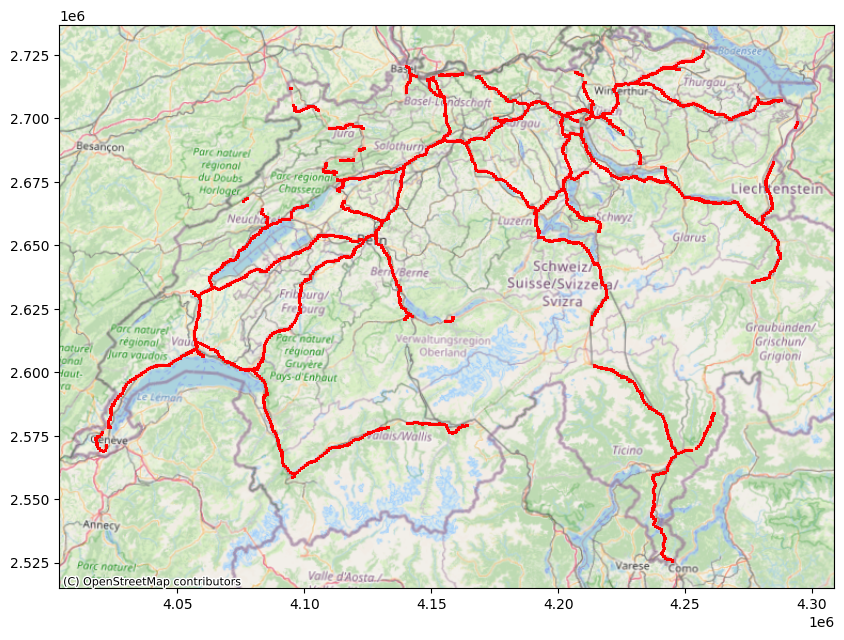

In [6]:
# Plot Dataset on Europe Map
gdf.plot(figsize=(10, 10), color="red", markersize=5)
ctx.add_basemap(
    plt.gca(),
    crs="EPSG:3035",
    source=ctx.providers.OpenStreetMap.Mapnik,
)

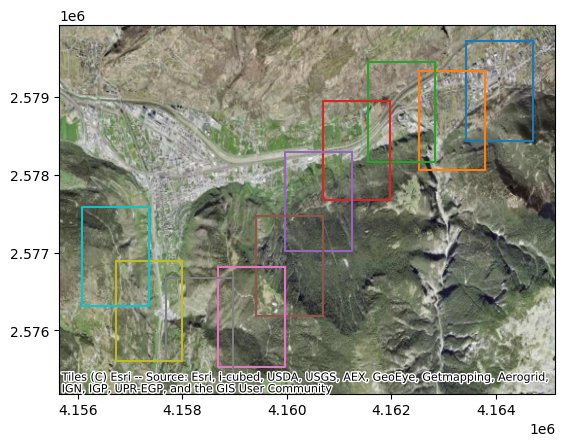

In [7]:
first_10 = gdf.geometry.head(10)
for geom in first_10:
    bbox = geom.bounds  # minx, miny, maxx, maxy
    plt.plot(*geom.exterior.xy)
ctx.add_basemap(
    plt.gca(),
    crs="EPSG:3035",
    source=ctx.providers.Esri.WorldImagery,
)
plt.show()

In [8]:
# for every point create a square around it and request a WMS crop centered on the point
img_format = "image/jpeg"
img_size = (
    int(buffer_size * 2 / PIXEL_RESOLUTION_M),
    int(buffer_size * 2 / PIXEL_RESOLUTION_M),
)  # width, height in pixels

In [11]:
# Multi-threaded version
image_output_dir = os.path.join(output_dir, "images")
os.makedirs(image_output_dir, exist_ok=True)

In [ ]:
# Download with parallel threads
# Set limit=None to download all, or limit=100 to download first 100, etc.
results = download_images_parallel(
    gdf=gdf,
    wms=wms,
    layer_name=layer_name,
    img_size=img_size,
    img_format=img_format,
    image_output_dir=image_output_dir,
    crs=CRS,
    max_workers=20,  # Number of parallel threads
    limit=None,  # None = download all, or set a number like 100
)

Starting parallel download of 1657 images using 20 threads...
Progress: 1/1657 (0.1%) - Rate: 0.50 img/s - ETA: 3334s
Progress: 2/1657 (0.1%) - Rate: 0.93 img/s - ETA: 1773s
Progress: 3/1657 (0.2%) - Rate: 1.39 img/s - ETA: 1191s
Progress: 4/1657 (0.2%) - Rate: 1.85 img/s - ETA: 895s
Progress: 5/1657 (0.3%) - Rate: 2.28 img/s - ETA: 726s
Progress: 6/1657 (0.4%) - Rate: 2.65 img/s - ETA: 623s
Progress: 7/1657 (0.4%) - Rate: 3.08 img/s - ETA: 536s
Progress: 8/1657 (0.5%) - Rate: 3.45 img/s - ETA: 478s
Progress: 9/1657 (0.5%) - Rate: 3.86 img/s - ETA: 427s
Progress: 10/1657 (0.6%) - Rate: 4.29 img/s - ETA: 384s
Progress: 11/1657 (0.7%) - Rate: 4.70 img/s - ETA: 350s
Progress: 12/1657 (0.7%) - Rate: 5.12 img/s - ETA: 321s
Progress: 13/1657 (0.8%) - Rate: 5.54 img/s - ETA: 297s
Progress: 14/1657 (0.8%) - Rate: 5.95 img/s - ETA: 276s
Progress: 15/1657 (0.9%) - Rate: 6.37 img/s - ETA: 258s
Progress: 16/1657 (1.0%) - Rate: 6.44 img/s - ETA: 255s
Progress: 17/1657 (1.0%) - Rate: 6.84 img/s - ET